## Build Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    # Strongly useful
    'study_hours'     : np.random.normal(6, 2, n).clip(0, 12),
    'attendance_pct'  : np.random.normal(75, 15, n).clip(0, 100),
    'prev_score'      : np.random.normal(65, 15, n).clip(0, 100),

    # Moderately useful
    'sleep_hours'     : np.random.normal(7, 1.5, n).clip(3, 10),
    'stress_level'    : np.random.randint(1, 10, n).astype(float),
    'exercise_days'   : np.random.randint(0, 7, n).astype(float),

    # Weakly useful
    'screen_time'     : np.random.normal(4, 2, n).clip(0, 12),
    'commute_time'    : np.random.normal(30, 15, n).clip(0, 120),

    # Pure noise
    'lucky_number'    : np.random.randint(1, 100, n).astype(float),
    'random_noise_1'  : np.random.normal(0, 1, n),
    'random_noise_2'  : np.random.uniform(0, 1, n),
    'student_id'      : np.arange(n).astype(float),
})

score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    df['exercise_days']  * 0.5 +
    np.random.normal(0, 5, n)
)
df['result'] = (score > score.median()).astype(int)

X = df.drop('result', axis=1)
y = df['result']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Total features : {len(feature_names)}")
print(f"Features       : {feature_names}")

Total features : 12
Features       : ['study_hours', 'attendance_pct', 'prev_score', 'sleep_hours', 'stress_level', 'exercise_days', 'screen_time', 'commute_time', 'lucky_number', 'random_noise_1', 'random_noise_2', 'student_id']


# RFE — Basic Version

In [2]:
# Choose base model for RFE
# Model must have feature_importances_ or coef_ attribute
# Random Forest, Logistic Regression, SVM all work

base_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

rfe = RFE(
    estimator  = base_model,
    # ↑ model used to rank features at each step

    n_features_to_select = 6,
    # ↑ how many features to keep in the end
    #   if you don't know → use RFECV to find automatically

    step       = 1,
    # ↑ how many features to remove per round
    #   step=1   → remove one at a time (slow but thorough)
    #   step=2   → remove two at a time (faster)
    #   step=0.1 → remove 10% at a time (for large feature sets)

    verbose    = 1
)

rfe.fit(X_train_scaled, y_train)

# Results
selected_mask     = rfe.support_
# ↑ True/False array — which features were selected

feature_ranking   = rfe.ranking_
# ↑ rank of each feature
#   1 = selected (all selected features get rank 1)
#   2 = removed second to last
#   higher = removed earlier (less important)

selected_features = [f for f, s in zip(feature_names, selected_mask) if s]
removed_features  = [f for f, s in zip(feature_names, selected_mask) if not s]

print("\nRFE Results:")
print(f"  Selected ({len(selected_features)}): {selected_features}")
print(f"  Removed  ({len(removed_features)}): {removed_features}")

print("\nFeature Rankings (1=selected, higher=removed earlier):")
rank_df = pd.DataFrame({
    'Feature': feature_names,
    'Rank'   : feature_ranking,
    'Selected': selected_mask
}).sort_values('Rank')
print(rank_df.to_string(index=False))

Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.

RFE Results:
  Selected (6): ['study_hours', 'attendance_pct', 'prev_score', 'sleep_hours', 'random_noise_1', 'student_id']
  Removed  (6): ['stress_level', 'exercise_days', 'screen_time', 'commute_time', 'lucky_number', 'random_noise_2']

Feature Rankings (1=selected, higher=removed earlier):
       Feature  Rank  Selected
   study_hours     1      True
attendance_pct     1      True
    prev_score     1      True
   sleep_hours     1      True
    student_id     1      True
random_noise_1     1      True
  commute_time     2     False
   screen_time     3     False
random_noise_2     4     False
  lucky_number     5     False
  stress_level     6     False
 exercise_days     7     False


# RFECV — Automatically Find Best Number of Features


RFECV Results:
  Optimal number of features : 8
  Selected features          : ['study_hours', 'attendance_pct', 'prev_score', 'sleep_hours', 'screen_time', 'commute_time', 'random_noise_1', 'student_id']


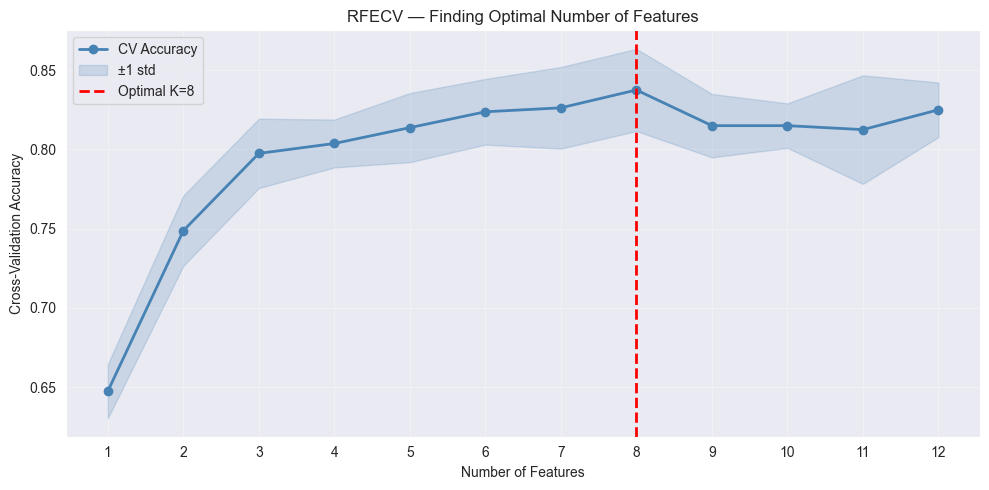

In [3]:
# RFE requires you to specify n_features_to_select
# RFECV finds the OPTIMAL number automatically using CV

rfecv = RFECV(
    estimator  = RandomForestClassifier(
                     n_estimators=100, random_state=42),

    step       = 1,
    # ↑ remove one feature per round

    cv         = StratifiedKFold(n_splits=5,
                                  shuffle=True,
                                  random_state=42),
    # ↑ use stratified 5-fold CV to evaluate each subset
    #   ensures class balance in each fold

    scoring    = 'accuracy',
    # ↑ metric to maximize
    #   can use: 'roc_auc', 'f1', 'accuracy'

    min_features_to_select = 1,
    # ↑ minimum features to consider
    #   never goes below this number

    n_jobs     = -1
)

rfecv.fit(X_train_scaled, y_train)

optimal_k         = rfecv.n_features_
selected_rfecv    = [f for f, s in zip(feature_names,
                                        rfecv.support_) if s]

print(f"\nRFECV Results:")
print(f"  Optimal number of features : {optimal_k}")
print(f"  Selected features          : {selected_rfecv}")

# Plot CV score vs number of features
cv_scores = rfecv.cv_results_['mean_test_score']
cv_stds   = rfecv.cv_results_['std_test_score']
n_features_range = range(1, len(cv_scores) + 1)

plt.figure(figsize=(10, 5))
plt.plot(n_features_range, cv_scores,
         marker='o', color='steelblue',
         linewidth=2, label='CV Accuracy')
plt.fill_between(n_features_range,
                 cv_scores - cv_stds,
                 cv_scores + cv_stds,
                 alpha=0.2, color='steelblue',
                 label='±1 std')
plt.axvline(x=optimal_k, color='red',
            linestyle='--', linewidth=2,
            label=f'Optimal K={optimal_k}')
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFECV — Finding Optimal Number of Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(n_features_range,
           [str(i) for i in n_features_range])
plt.tight_layout()
plt.show()

# Forward Selection — Manual Implementation

In [4]:
def forward_selection(X, y, model, scoring='accuracy', cv=5):
    """
    Greedy forward feature selection.
    Starts with no features, adds best one each round.
    Stops when no feature improves CV score.
    """
    remaining    = list(range(X.shape[1]))  # all feature indices
    selected     = []                        # start with empty set
    best_score   = 0.0
    history      = []                        # track scores over rounds

    print("Forward Selection Progress:")
    print(f"{'Round':>6} {'Added Feature':>25} {'CV Score':>10} {'Improvement':>13}")
    print("─" * 60)

    while remaining:
        round_scores = {}

        # Try adding each remaining feature
        for feature_idx in remaining:
            candidate = selected + [feature_idx]
            X_candidate = X[:, candidate]

            scores = cross_val_score(
                model, X_candidate, y,
                cv=cv, scoring=scoring
            )
            round_scores[feature_idx] = scores.mean()

        # Pick the feature that improved score the most
        best_new_feature = max(round_scores,
                                key=round_scores.get)
        best_new_score   = round_scores[best_new_feature]
        improvement      = best_new_score - best_score

        feature_name = feature_names[best_new_feature]

        print(f"{len(selected)+1:>6} {feature_name:>25} "
              f"{best_new_score:>10.4f} {improvement:>+13.4f}")

        # Only add if it actually improves score
        if best_new_score > best_score + 0.001:
            selected.append(best_new_feature)
            remaining.remove(best_new_feature)
            best_score = best_new_score
            history.append({
                'n_features' : len(selected),
                'feature'    : feature_name,
                'cv_score'   : best_new_score
            })
        else:
            print(f"\n  No improvement — stopping at "
                  f"{len(selected)} features")
            break

    selected_names = [feature_names[i] for i in selected]
    return selected_names, history


# Run forward selection
model_lr = LogisticRegression(max_iter=1000, random_state=42)

forward_selected, forward_history = forward_selection(
    X_train_scaled, y_train,
    model   = model_lr,
    scoring = 'accuracy',
    cv      = 5
)

print(f"\nForward Selection Final Features: {forward_selected}")

Forward Selection Progress:
 Round             Added Feature   CV Score   Improvement
────────────────────────────────────────────────────────────
     1               study_hours     0.7375       +0.7375
     2                prev_score     0.8150       +0.0775
     3            attendance_pct     0.8275       +0.0125
     4               sleep_hours     0.8488       +0.0213
     5              lucky_number     0.8500       +0.0012
     6            random_noise_2     0.8525       +0.0025
     7              commute_time     0.8488       -0.0037

  No improvement — stopping at 6 features

Forward Selection Final Features: ['study_hours', 'prev_score', 'attendance_pct', 'sleep_hours', 'lucky_number', 'random_noise_2']


# Backward Elimination — Manual Implementation

In [5]:
def backward_elimination(X, y, model, scoring='accuracy', cv=5):
    """
    Greedy backward feature elimination.
    Starts with all features, removes worst one each round.
    Stops when removing any feature hurts performance.
    """
    selected   = list(range(X.shape[1]))  # start with ALL features
    history    = []

    # Get baseline score with all features
    base_scores = cross_val_score(model, X, y,
                                   cv=cv, scoring=scoring)
    best_score  = base_scores.mean()

    print("Backward Elimination Progress:")
    print(f"Baseline score (all {len(selected)} features): "
          f"{best_score:.4f}\n")
    print(f"{'Round':>6} {'Removed Feature':>25} "
          f"{'CV Score':>10} {'Change':>10}")
    print("─" * 55)

    while len(selected) > 1:
        round_scores = {}

        # Try removing each current feature
        for feature_idx in selected:
            candidate    = [f for f in selected if f != feature_idx]
            X_candidate  = X[:, candidate]

            scores = cross_val_score(
                model, X_candidate, y,
                cv=cv, scoring=scoring
            )
            round_scores[feature_idx] = scores.mean()

        # Feature whose removal hurts LEAST
        # (or improves score)
        best_to_remove      = max(round_scores,
                                   key=round_scores.get)
        score_after_removal = round_scores[best_to_remove]
        change              = score_after_removal - best_score
        feature_name        = feature_names[best_to_remove]

        print(f"{len(selected)-1:>6} {feature_name:>25} "
              f"{score_after_removal:>10.4f} {change:>+10.4f}")

        # Remove if score doesn't drop more than threshold
        if score_after_removal >= best_score - 0.002:
            selected.remove(best_to_remove)
            best_score = score_after_removal
            history.append({
                'n_features'    : len(selected),
                'removed'       : feature_name,
                'cv_score'      : score_after_removal
            })
        else:
            print(f"\n  Removing any feature drops score "
                  f"significantly — stopping")
            break

    selected_names = [feature_names[i] for i in selected]
    return selected_names, history


backward_selected, backward_history = backward_elimination(
    X_train_scaled, y_train,
    model   = model_lr,
    scoring = 'accuracy',
    cv      = 5
)

print(f"\nBackward Elimination Final Features: {backward_selected}")

Backward Elimination Progress:
Baseline score (all 12 features): 0.8337

 Round           Removed Feature   CV Score     Change
───────────────────────────────────────────────────────
    11               screen_time     0.8413    +0.0075
    10              stress_level     0.8450    +0.0037
     9              commute_time     0.8475    +0.0025
     8            random_noise_2     0.8463    -0.0012
     7            random_noise_1     0.8475    +0.0012
     6              lucky_number     0.8488    +0.0013
     5                student_id     0.8488    +0.0000
     4             exercise_days     0.8488    +0.0000
     3               sleep_hours     0.8275    -0.0213

  Removing any feature drops score significantly — stopping

Backward Elimination Final Features: ['study_hours', 'attendance_pct', 'prev_score', 'sleep_hours']


# Compare All Wrapper Methods


Final Comparison:
Method                      N Features   Test Acc   Test AUC    Test F1
────────────────────────────────────────────────────────────────────────
All Features                        12     0.8200     0.9034     0.8125
RFE (K=6)                            6     0.8450     0.9095     0.8426
RFECV (auto)                         8     0.8250     0.9058     0.8223
Forward Selection                    6     0.8150     0.8971     0.8103
Backward Elim                        4     0.8200     0.8845     0.8163


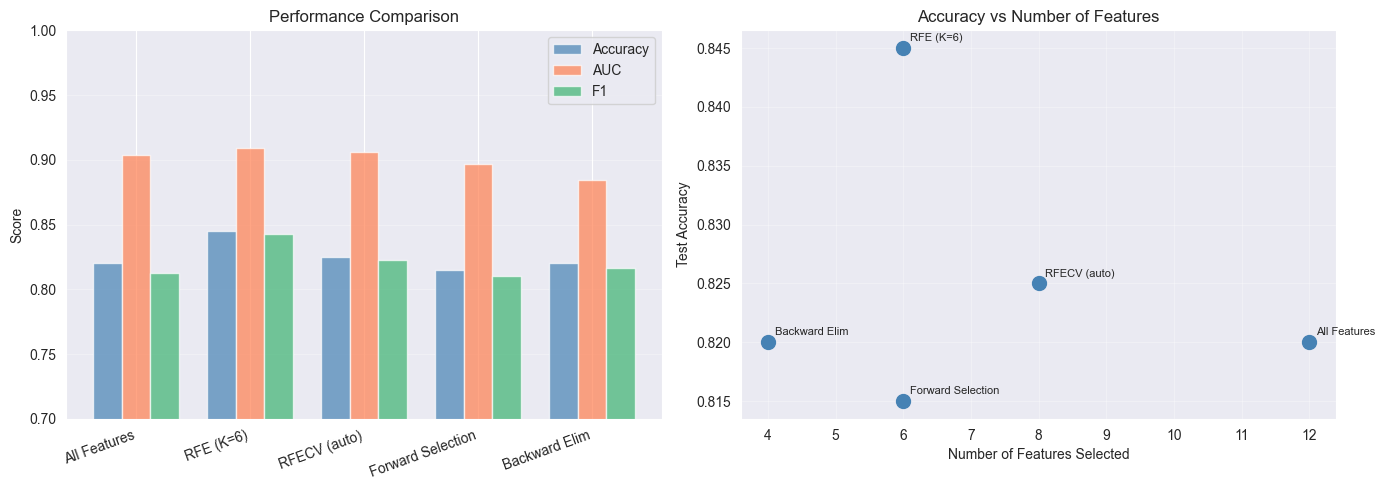

In [6]:
# Evaluate each method's selected features on test set

methods = {
    'All Features'       : feature_names,
    'RFE (K=6)'          : selected_features,
    'RFECV (auto)'       : selected_rfecv,
    'Forward Selection'  : forward_selected,
    'Backward Elim'      : backward_selected,
}

print("\nFinal Comparison:")
print(f"{'Method':<25} {'N Features':>12} "
      f"{'Test Acc':>10} {'Test AUC':>10} {'Test F1':>10}")
print("─" * 72)

comparison_results = {}

for method_name, features in methods.items():
    # Get indices of selected features
    feat_idx = [feature_names.index(f) for f in features]

    X_tr = X_train_scaled[:, feat_idx]
    X_te = X_test_scaled[:,  feat_idx]

    # Train and evaluate
    model_rf = RandomForestClassifier(
                   n_estimators=100, random_state=42)
    model_rf.fit(X_tr, y_train)

    preds = model_rf.predict(X_te)
    probs = model_rf.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_test, preds)
    auc  = roc_auc_score(y_test, probs)
    f1   = f1_score(y_test, preds)

    comparison_results[method_name] = {
        'N_Features': len(features),
        'Accuracy'  : acc,
        'AUC'       : auc,
        'F1'        : f1,
        'Features'  : features
    }

    print(f"{method_name:<25} {len(features):>12} "
          f"{acc:>10.4f} {auc:>10.4f} {f1:>10.4f}")

# Plot comparison
comp_df = pd.DataFrame(comparison_results).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Metrics comparison
x      = np.arange(len(comp_df))
width  = 0.25

axes[0].bar(x - width, comp_df['Accuracy'].astype(float),
            width, label='Accuracy', color='steelblue', alpha=0.7)
axes[0].bar(x,          comp_df['AUC'].astype(float),
            width, label='AUC',      color='coral', alpha=0.7)
axes[0].bar(x + width,  comp_df['F1'].astype(float),
            width, label='F1',       color='mediumseagreen', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comp_df.index, rotation=20, ha='right')
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title("Performance Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2 — Number of features vs accuracy
axes[1].scatter(
    comp_df['N_Features'].astype(int),
    comp_df['Accuracy'].astype(float),
    s=100, color='steelblue', zorder=5
)
for idx, row in comp_df.iterrows():
    axes[1].annotate(
        idx,
        (int(row['N_Features']),
         float(row['Accuracy'])),
        textcoords="offset points",
        xytext=(5, 5), fontsize=8
    )
axes[1].set_xlabel("Number of Features Selected")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Accuracy vs Number of Features")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()